# PTB-XL Improved Training Pipeline

## Objective

This notebook is the first post-baseline experiment. It uses the reusable data, training, and evaluation modules to train a regularized residual 1D CNN, reduce the effect of class imbalance, and select per-class decision thresholds using the validation set.

The held-out test fold is evaluated only after all training and threshold choices are complete, preserving an unbiased final estimate of model performance.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

current_path = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (current_path, *current_path.parents)
     if (path / 'src').is_dir() and (path / 'data' / 'ptb-xl').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the project root.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data' / 'ptb-xl'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('PyTorch version:', torch.__version__)

Project root: /Users/jerrywong/ML-repos/ecg-classification
PyTorch version: 2.13.0


In [2]:
from src.data import (
    DIAGNOSTIC_CLASSES,
    build_dataloaders,
    build_datasets,
    compute_pos_weights,
    prepare_ptbxl_splits,
)
from src.evaluation import (
    evaluate_multilabel,
    optimize_f1_thresholds,
    predict_probabilities,
)
from src.model import ECGCNN, ResidualECGCNN
from src.training import fit, load_model_state, seed_everything, select_device

## 2. Experiment Configuration

The class weights use the square root of the usual negative-to-positive ratio. This gives rare diagnoses more influence without the aggressive over-correction that full inverse-frequency weighting can produce.

In [3]:
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4
CHECKPOINT_PATH = MODEL_DIR / 'residual_ecg_cnn.pt'

seed_everything(SEED)
device = select_device()
print('Using device:', device)

Using device: mps


## 3. Reusable Data Pipeline

PTB-XL folds 1-8 are used for training, fold 9 for validation, and fold 10 for the final test. Normalization statistics are computed from the training recordings only.

In [4]:
splits = prepare_ptbxl_splits(DATA_DIR)
datasets = build_datasets(splits, DATA_DIR)
loaders = build_dataloaders(
    datasets,
    batch_size=BATCH_SIZE,
    pin_memory=device.type == 'cuda',
)

split_sizes = pd.Series({
    'Train': len(splits.train),
    'Validation': len(splits.val),
    'Test': len(splits.test),
}, name='Recordings')
display(split_sizes.to_frame())
print('Normalization shapes:', datasets.stats.mean.shape, datasets.stats.std.shape)

,Recordings
Train,17084
Validation,2146
Test,2158


Normalization shapes: (12,) (12,)


In [5]:
positive_counts = np.vstack(splits.train['labels']).sum(axis=0)
pos_weights = compute_pos_weights(splits.train, power=0.5)
class_balance = pd.DataFrame({
    'Training positives': positive_counts.astype(int),
    'Positive weight': pos_weights,
}, index=DIAGNOSTIC_CLASSES)
display(class_balance.round(3))

,Training positives,Positive weight
NORM,7596,1.118
MI,4379,1.703
STTC,4186,1.755
CD,3907,1.836
HYP,2119,2.657


## 4. Residual CNN Training

The residual model is deeper than the prototype CNN, while skip connections stabilize optimization. Dropout, AdamW weight decay, learning-rate reduction, and early stopping control overfitting. The best validation-loss checkpoint is restored automatically.

In [6]:
model = ResidualECGCNN(num_classes=len(DIAGNOSTIC_CLASSES), dropout=0.3)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weights, dtype=torch.float32, device=device)
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('Trainable parameters:', f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 1,835,909


In [7]:
training_result = fit(
    model=model,
    train_loader=loaders.train,
    val_loader=loaders.val,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    checkpoint_path=CHECKPOINT_PATH,
    scheduler=scheduler,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
)
print('Best epoch:', training_result.best_epoch)
print('Best validation loss:', round(training_result.best_val_loss, 4))

Epoch 01/20 | Train loss: 0.4705 | Validation loss: 0.5240
Epoch 02/20 | Train loss: 0.4136 | Validation loss: 0.4377
Epoch 03/20 | Train loss: 0.3950 | Validation loss: 0.4107
Epoch 04/20 | Train loss: 0.3786 | Validation loss: 0.3945
Epoch 05/20 | Train loss: 0.3675 | Validation loss: 0.4270
Epoch 06/20 | Train loss: 0.3591 | Validation loss: 0.3876
Epoch 07/20 | Train loss: 0.3509 | Validation loss: 0.3997
Epoch 08/20 | Train loss: 0.3435 | Validation loss: 0.4074
Epoch 09/20 | Train loss: 0.3373 | Validation loss: 0.4201
Epoch 10/20 | Train loss: 0.3142 | Validation loss: 0.3879
Early stopping after epoch 10; best epoch: 6
Best epoch: 6
Best validation loss: 0.3876


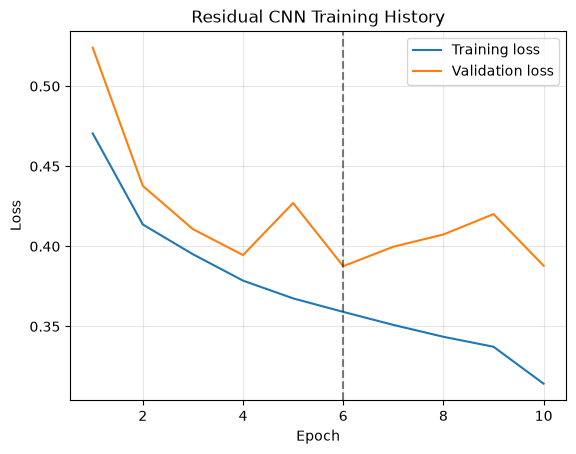

In [8]:
epochs = range(1, len(training_result.history.train_loss) + 1)
plt.plot(epochs, training_result.history.train_loss, label='Training loss')
plt.plot(epochs, training_result.history.val_loss, label='Validation loss')
plt.axvline(training_result.best_epoch, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Residual CNN Training History')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Validation-Based Threshold Selection

A threshold of 0.5 is not necessarily optimal for an imbalanced multi-label problem. Each class threshold is selected to maximize F1 on the validation fold only. The test labels are not used during this decision.

In [9]:
validation_predictions = predict_probabilities(model, loaders.val, device)
threshold_candidates = np.linspace(0.05, 0.95, 37)
selected_thresholds = optimize_f1_thresholds(
    validation_predictions.labels,
    validation_predictions.probabilities,
    candidates=threshold_candidates,
)
threshold_table = pd.Series(
    selected_thresholds, index=DIAGNOSTIC_CLASSES, name='Threshold'
)
display(threshold_table.round(3).to_frame())

,Threshold
NORM,0.350
MI,0.450
STTC,0.475
CD,0.675
HYP,0.525


## 6. One-Time Held-Out Test Evaluation

This section is intended for use only after the architecture, loss, regularization, and thresholds are fixed. AUROC is presented together with threshold-dependent F1 and sensitivity for a balanced account of model performance.

In [10]:
test_predictions = predict_probabilities(model, loaders.test, device)
fixed_metrics = evaluate_multilabel(
    test_predictions.labels,
    test_predictions.probabilities,
    threshold=0.5,
)
tuned_metrics = evaluate_multilabel(
    test_predictions.labels,
    test_predictions.probabilities,
    threshold=selected_thresholds,
)

print('Per-class results with validation-selected thresholds')
display(tuned_metrics.per_class.round(3))
comparison = pd.concat(
    [fixed_metrics.overall.rename(columns={'Score': 'Threshold 0.5'}),
     tuned_metrics.overall.rename(columns={'Score': 'Validation-tuned'})],
    axis=1,
)
display(comparison.round(3))

Per-class results with validation-selected thresholds


,TP,FP,TN,FN,Precision,Sensitivity,Specificity,F1,AUROC
Class,,,,,,,,,
NORM,893,241,954,70,0.787,0.927,0.798,0.852,0.939
MI,430,224,1384,120,0.657,0.782,0.861,0.714,0.906
STTC,437,208,1429,84,0.678,0.839,0.873,0.750,0.930
CD,336,74,1588,160,0.820,0.677,0.955,0.742,0.913
HYP,151,81,1815,111,0.651,0.576,0.957,0.611,0.898


,Threshold 0.5,Validation-tuned
Macro F1,0.738,0.734
Micro F1,0.767,0.766
Macro AUROC,0.917,0.917
Micro AUROC,0.929,0.929


### Saved Baseline Comparison

For a like-for-like reference, calibrate the completed baseline on the same validation fold and evaluate its existing checkpoint on the test fold. This cell reproduces the calibrated baseline metrics quoted in the README.

In [11]:
BASELINE_PATH = MODEL_DIR / 'baseline_ecg_cnn.pt'
if BASELINE_PATH.is_file():
    baseline_model = load_model_state(
        ECGCNN(num_classes=len(DIAGNOSTIC_CLASSES)), BASELINE_PATH, device
    )
    baseline_validation = predict_probabilities(baseline_model, loaders.val, device)
    baseline_thresholds = optimize_f1_thresholds(
        baseline_validation.labels,
        baseline_validation.probabilities,
        candidates=threshold_candidates,
    )
    baseline_test = predict_probabilities(baseline_model, loaders.test, device)
    baseline_metrics = evaluate_multilabel(
        baseline_test.labels,
        baseline_test.probabilities,
        threshold=baseline_thresholds,
    )
    model_comparison = pd.concat(
        [baseline_metrics.overall.rename(columns={'Score': 'Calibrated baseline'}),
         tuned_metrics.overall.rename(columns={'Score': 'Residual CNN'})],
        axis=1,
    )
    display(model_comparison.round(3))
else:
    print('Baseline checkpoint not found:', BASELINE_PATH)

,Calibrated baseline,Residual CNN
Macro F1,0.729,0.734
Micro F1,0.761,0.766
Macro AUROC,0.916,0.917
Micro AUROC,0.927,0.929


In [12]:
final_metrics = tuned_metrics.overall['Score']
print(
    'Final model summary: The residual 1D CNN was trained on 17,084 PTB-XL '
    f"ECGs and achieved {final_metrics['Macro AUROC']:.3f} macro AUROC, "
    f"{final_metrics['Macro F1']:.3f} macro F1, and "
    f"{final_metrics['Micro F1']:.3f} micro F1 on the held-out test fold."
)

Final model summary: The residual 1D CNN was trained on 17,084 PTB-XL ECGs and achieved 0.917 macro AUROC, 0.734 macro F1, and 0.766 micro F1 on the held-out test fold.


## 7. Interpretation and Next Experiment

The calibrated saved baseline achieved macro F1 of approximately **0.729**, micro F1 of **0.761**, macro AUROC of **0.916**, and micro AUROC of **0.927**. The residual model is considered an improvement only when its validation performance improves and the gain is subsequently confirmed on the held-out test fold.

Potential controlled experiments include signal augmentation, a small learning-rate and batch-size sweep, and repeated-seed confidence intervals. Fold 10 remains reserved for final evaluation, while validation or cross-validation supports model selection.